## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

In [3]:
# Path to BIDMC PhysioNet dataset
data_dir = Path(
    r"G:\1-1- Articles\1- Hybrid_Quantum_STATE_PREPRATION_VIA_DATA_COMPRESSION\Datasets\bidmc-ppg-and-respiration-dataset-1.0.0\bidmc_csv"
)

signal_files = sorted(
    data_dir.glob("*_Signals.csv")
)

print(f"Found {len(signal_files)} files")

Found 53 files


In [6]:
def load_ppg_signal(file_path):
    """
    Load a PPG waveform, zero-pad it to the next
    power of two, and normalize it.
    """

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip()

    signal = df["PLETH"].astype(float).values

    # Zero-padding
    N_orig = len(signal)

    next_pow2 = 2 ** math.ceil(
        math.log2(N_orig)
    )

    pad_len = next_pow2 - N_orig

    signal = np.pad(
        signal,
        (0, pad_len),
        mode="constant"
    )

    # Normalization
    signal = (
        signal /
        np.linalg.norm(signal)
    )

    return signal

In [4]:
# ------------------------------------------------------------
# Evaluate all decomposition levels for a given sparsity k
# ------------------------------------------------------------

def analyze_ppg_dataset(k):

    levels = range(1, 10)

    all_td = []

    for file in signal_files:

        # ----------------------------------------------------
        # Load first 1024 samples
        # ----------------------------------------------------

        signal = load_ppg_signal(file)[:1024]
        signal /= np.linalg.norm(signal)

        td_per_level = []

        # ----------------------------------------------------
        # Test every packet decomposition level
        # ----------------------------------------------------

        for level in levels:

            coeffs = haar_packet_transform(
                signal,
                level
            )

            coeffs = top_k_threshold(
                coeffs,
                k
            )

            coeffs /= np.linalg.norm(coeffs)

            reconstructed = inverse_haar_packet_transform(
                coeffs,
                level
            )

            td = trace_distance(
                signal,
                reconstructed
            )

            td_per_level.append(td)

        all_td.append(td_per_level)

    all_td = np.asarray(all_td)

    return (
        all_td.mean(axis=0),
        all_td.std(axis=0)
    )

In [11]:
n = 10

k_values = {
    r"$k=n$":      n,
    r"$k=5n$":     5*n,
    r"$k=n^2$":    n**2,
    r"$k=2n^2$":   2*n**2,
}

results = {}

for label, k in k_values.items():

    print(f"Running {label} (k={k})")

    mean_td, std_td = analyze_ppg_dataset(k)

    results[label] = (
        mean_td,
        std_td
    )

Running $k=n$ (k=10)
Running $k=5n$ (k=50)
Running $k=n^2$ (k=100)
Running $k=2n^2$ (k=200)


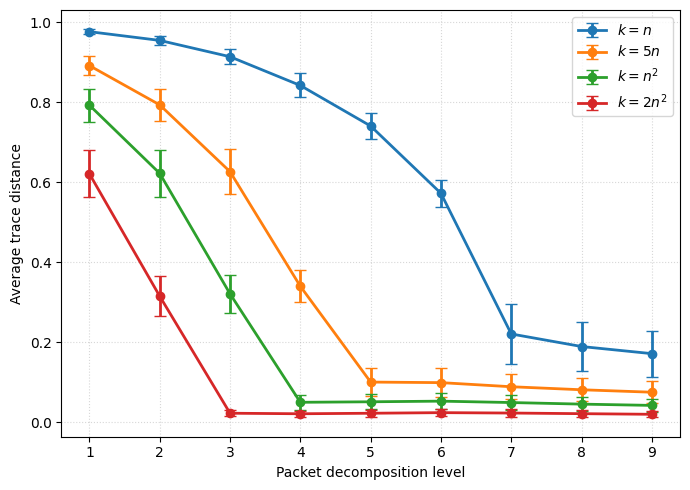

In [13]:
import matplotlib.pyplot as plt

levels = np.arange(1, 10)

plt.figure(figsize=(7,5))

for label, (mean_td, std_td) in results.items():

    plt.errorbar(
        levels,
        mean_td,
        yerr=std_td,
        marker="o",
        linewidth=2,
        capsize=4,
        label=label
    )

plt.xlabel("Packet decomposition level")
plt.ylabel("Average trace distance")

plt.grid(
    True,
    linestyle=":",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.savefig("../figures/PPG_dataset_analysis.pdf")
plt.show()